In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [45]:
# Informações gerais
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["classe"] = cancer.target
df["nome_classe"] = [cancer.target_names[t] for t in cancer.target]

print("Informações do dataset")
print(f"Shape(linhas x colunas): {df.shape}")
print(f"Total de amostras:{cancer.data.shape[0]}")
print(f"Total de features:{cancer.data.shape[1]}")
print()
print("Classes:")
for i, nome in enumerate(cancer.target_names):
    qtd = (cancer.target == i).sum()
    print(f"{i} = {nome}:{qtd} amostras")
print()
print("Features disponíveis:")
for i, f in enumerate(cancer.feature_names):
    print(f"{i+1:2d}.{f}")

Informações do dataset
Shape(linhas x colunas): (569, 32)
Total de amostras:569
Total de features:30

Classes:
0 = malignant:212 amostras
1 = benign:357 amostras

Features disponíveis:
 1.mean radius
 2.mean texture
 3.mean perimeter
 4.mean area
 5.mean smoothness
 6.mean compactness
 7.mean concavity
 8.mean concave points
 9.mean symmetry
10.mean fractal dimension
11.radius error
12.texture error
13.perimeter error
14.area error
15.smoothness error
16.compactness error
17.concavity error
18.concave points error
19.symmetry error
20.fractal dimension error
21.worst radius
22.worst texture
23.worst perimeter
24.worst area
25.worst smoothness
26.worst compactness
27.worst concavity
28.worst concave points
29.worst symmetry
30.worst fractal dimension


C:\Users\User\AppData\Local\Temp\ipykernel_14916\1403617232.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([maligno, benigno], labels=["Maligno", "Benigno"], patch_artist=True)


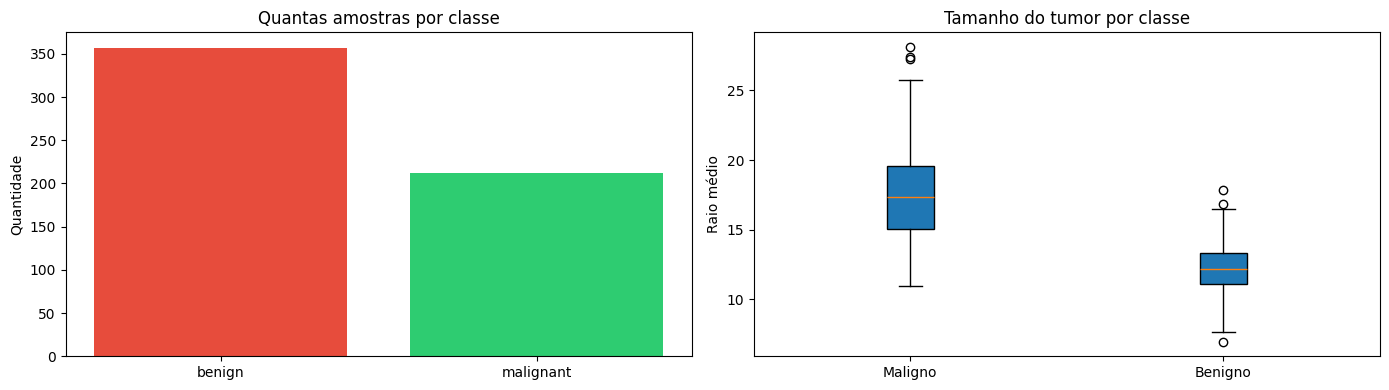

In [46]:
# Graficos
fig, axes = plt.subplots(1, 2,figsize=(14,4))

# quantas amostras de cada classe
contagem = df["nome_classe"].value_counts()
axes[0].bar(contagem.index, contagem.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Quantas amostras por classe")
axes[0].set_ylabel("Quantidade")

# o raio médio do tumor maligno != benigno
maligno = df[df["classe"] == 0]["mean radius"]
benigno = df[df["classe"] == 1]["mean radius"]
axes[1].boxplot([maligno, benigno], labels=["Maligno", "Benigno"], patch_artist=True)
axes[1].set_title("Tamanho do tumor por classe")
axes[1].set_ylabel("Raio médio")


plt.tight_layout()
plt.show()

In [47]:
# Pré-processamento
X = df[cancer.feature_names]
y = df["classe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# normalização dos dados
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [48]:
#Teste de '1 a 20
k_values = range(1, 21)
acuracias = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_s, y_train)
    acc = modelo.score(X_test_s, y_test)
    acuracias.append(acc)
    print(f"k={k:2d} - Acurácia: {acc:.4f}")

k= 1 - Acurácia: 0.9510
k= 2 - Acurácia: 0.9371
k= 3 - Acurácia: 0.9720
k= 4 - Acurácia: 0.9580
k= 5 - Acurácia: 0.9790
k= 6 - Acurácia: 0.9720
k= 7 - Acurácia: 0.9790
k= 8 - Acurácia: 0.9720
k= 9 - Acurácia: 0.9650
k=10 - Acurácia: 0.9650
k=11 - Acurácia: 0.9720
k=12 - Acurácia: 0.9790
k=13 - Acurácia: 0.9580
k=14 - Acurácia: 0.9650
k=15 - Acurácia: 0.9580
k=16 - Acurácia: 0.9580
k=17 - Acurácia: 0.9510
k=18 - Acurácia: 0.9510
k=19 - Acurácia: 0.9510
k=20 - Acurácia: 0.9510


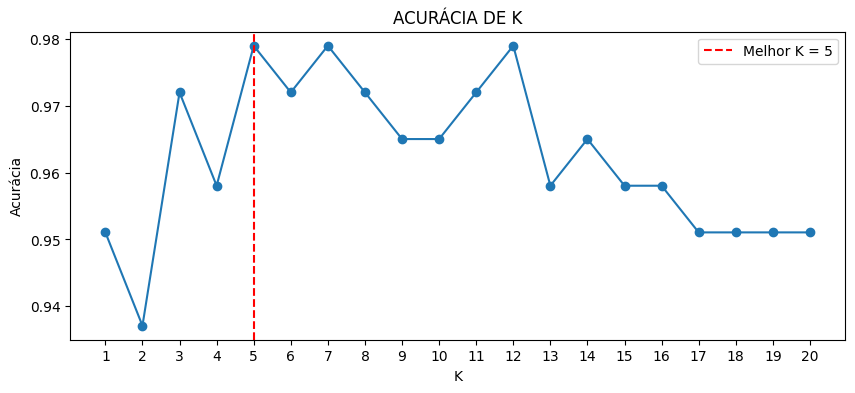

Melhor K: 5 - Acurácia: 97.90%


In [49]:
# Gráfico de acurácia
melhor_k = list(k_values)[acuracias.index(max(acuracias))]

plt.figure(figsize=(10, 4))
plt.plot(list(k_values), acuracias, marker="o")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"Melhor K = {melhor_k}")
plt.xticks(list(k_values))
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.title("ACURÁCIA DE K")
plt.legend()
plt.show()

print(f"Melhor K: {melhor_k} - Acurácia: {max(acuracias)*100:.2f}%")

In [50]:
#Resultado
modelo_final = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_final.fit(X_train_s, y_train)
y_pred = modelo_final.predict(X_test_s)

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Maligno", "Benigno"]
))

              precision    recall  f1-score   support

     Maligno       1.00      0.94      0.97        53
     Benigno       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143

